## Análisis bivariable

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Segundo notebook de `3-analysis`. Estudia las relaciones **entre pares de variables**,
sobre el dataset tipado en `2-exploration` (471 x 8):

1. Cada predictor contra el target `chance_of_admit`, con una medida de asociación
   comparable entre tipos de variable.
2. Los predictores numéricos entre sí, para detectar redundancia antes de modelar.
3. Las dos variables categóricas entre sí.
4. Las categóricas contra las numéricas.

**Continúa** el análisis por atributo de `03.1`; las interacciones de tres o más
variables y el modelo heurístico están en `03.3`.

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)

print(f"pandas     {pd.__version__}")
print(f"seaborn    {sns.__version__}")
print(f"scipy      {scipy.__version__}")

pandas     3.0.5
seaborn    0.13.2
scipy      1.18.0


## ⚙️ Configuración

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


ARCHIVO_ENTRADA = (
    buscar_raiz_proyecto() / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
)

COLS_NUMERICAS = ["gre_score", "toefl_score", "sop", "lor", "cgpa"]
TARGET = "chance_of_admit"

sns.set_theme(style="whitegrid", palette="deep")
print(f"Entrada: {ARCHIVO_ENTRADA.relative_to(ARCHIVO_ENTRADA.parents[2])}")

Entrada: data/02_intermediate/admisiones_type_fixed.parquet


## 💾 Load data

In [3]:
df = pd.read_parquet(ARCHIVO_ENTRADA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gre_score          460 non-null    Int64   
 1   toefl_score        452 non-null    Int64   
 2   university_rating  465 non-null    category
 3   sop                455 non-null    Float64 
 4   lor                463 non-null    Float64 
 5   cgpa               469 non-null    Float64 
 6   research           442 non-null    boolean 
 7   chance_of_admit    471 non-null    Float64 
dtypes: Float64(4), Int64(2), boolean(1), category(1)
memory usage: 26.4 KB


## 🎯 Target vs. variables numéricas

El target es continuo, así que la herramienta natural es el **diagrama de dispersión**
más dos correlaciones:

- **Pearson**, que mide asociación *lineal*.
- **Spearman**, que mide asociación *monótona* (sube o baja de forma consistente,
  aunque no sea en línea recta) y es robusta a valores extremos.

Si ambas son parecidas, la relación es esencialmente lineal. Si Spearman es bastante
mayor que Pearson, hay una relación monótona pero curva.

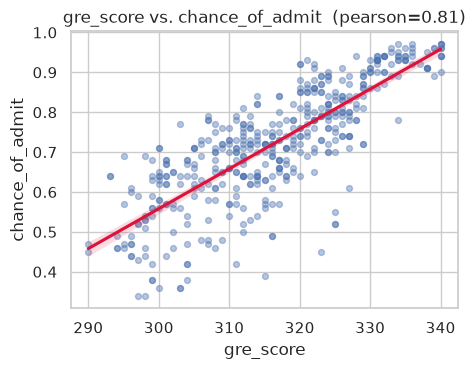

n = 460   pearson = 0.808 (p = 3.8e-107)   spearman = 0.820


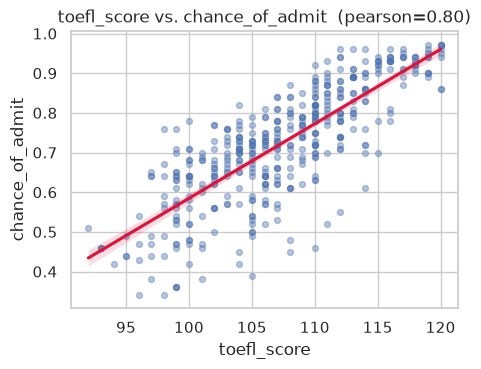

n = 452   pearson = 0.803 (p = 2.7e-103)   spearman = 0.809


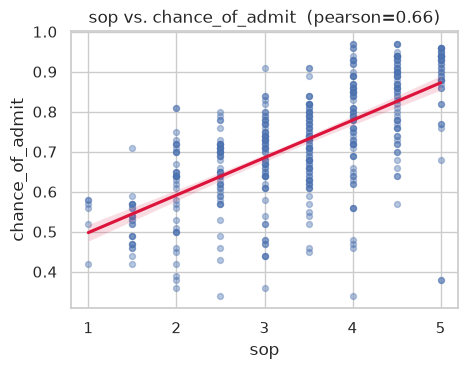

n = 455   pearson = 0.663 (p = 6.6e-59)   spearman = 0.682


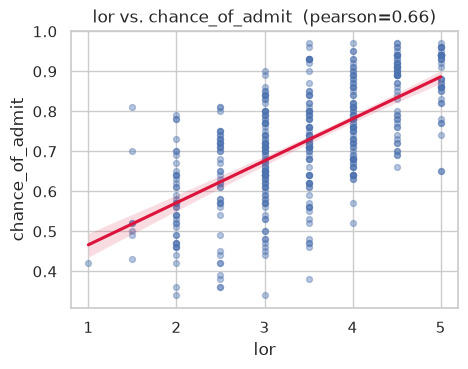

n = 463   pearson = 0.660 (p = 3.4e-59)   spearman = 0.657


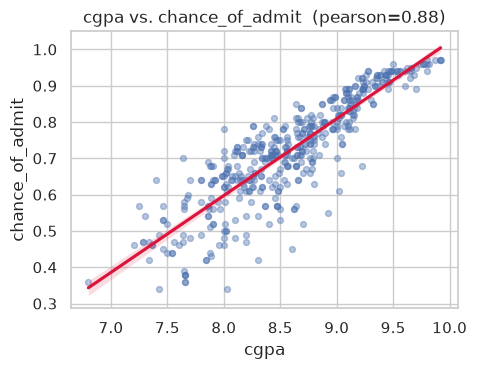

n = 469   pearson = 0.877 (p = 6.7e-151)   spearman = 0.881


,pearson,spearman,n
columna,,,
cgpa,0.877,0.881,469
gre_score,0.808,0.820,460
toefl_score,0.803,0.809,452
sop,0.663,0.682,455
lor,0.660,0.657,463


In [4]:
def dispersion_vs_target(df: pd.DataFrame, columna: str) -> dict:
    """Scatter con recta de ajuste + correlaciones de Pearson y Spearman."""
    pareja = df[[columna, TARGET]].dropna().astype(float)
    pearson, p_pearson = stats.pearsonr(pareja[columna], pareja[TARGET])
    spearman, _ = stats.spearmanr(pareja[columna], pareja[TARGET])

    _, ax = plt.subplots(figsize=(5, 3.6))
    sns.regplot(
        data=pareja,
        x=columna,
        y=TARGET,
        scatter_kws={"alpha": 0.4, "s": 18},
        line_kws={"color": "crimson"},
        ax=ax,
    )
    ax.set_title(f"{columna} vs. {TARGET}  (pearson={pearson:.2f})")
    plt.show()

    print(
        f"n = {len(pareja)}   pearson = {pearson:.3f} (p = {p_pearson:.1e})   spearman = {spearman:.3f}"
    )
    return {"columna": columna, "pearson": pearson, "spearman": spearman, "n": len(pareja)}


correlaciones = [dispersion_vs_target(df, columna) for columna in COLS_NUMERICAS]
pd.DataFrame(correlaciones).set_index("columna").round(3).sort_values("pearson", ascending=False)

**Lectura:**

| Variable | Pearson | Spearman | Interpretación |
|---|---|---|---|
| `cgpa` | 0.877 | 0.881 | el predictor individual más fuerte |
| `gre_score` | 0.808 | 0.820 | muy fuerte |
| `toefl_score` | 0.803 | 0.809 | muy fuerte |
| `sop` | 0.663 | 0.682 | moderado |
| `lor` | 0.660 | 0.657 | moderado |

Pearson y Spearman coinciden en todas las variables (diferencias < 0.02), así que las
relaciones son **aproximadamente lineales**: no hace falta una transformación
polinómica ni un cambio de escala para capturarlas. Todos los p-valores son
prácticamente cero, pero eso dice poco con n ≈ 460: lo informativo es la magnitud, no
la significancia.

En los diagramas de `sop` y `lor` los puntos aparecen alineados en columnas verticales
porque son escalas discretas de 9 niveles, no porque haya un patrón oculto.

## 🎯 Target vs. variables categóricas

Aquí sí tiene sentido el **boxplot por grupo** más las medias por categoría. Para
`research`, que es binaria, se añade una prueba t de Welch y el tamaño del efecto
(*d* de Cohen), que dice si la diferencia es grande, no solo si es significativa.

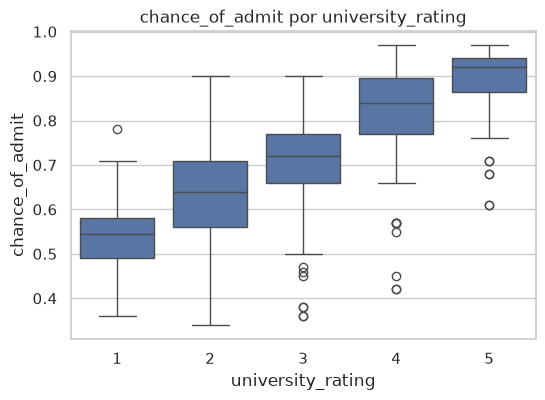

                   count   mean  median    std
university_rating                             
1                     28  0.546   0.545  0.088
2                    121  0.629    0.64   0.11
3                    158  0.707    0.72  0.102
4                     83   0.81    0.84  0.122
5                     75  0.885    0.92  0.082

spearman(university_rating, chance_of_admit) = 0.711 (p = 7.4e-73)


In [5]:
_, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="university_rating",
    y=TARGET,
    order=sorted(df["university_rating"].dropna().unique()),
    ax=ax,
)
ax.set_title(f"{TARGET} por university_rating")
plt.show()

resumen_rating = df.groupby("university_rating", observed=True)[TARGET].agg(
    ["count", "mean", "median", "std"]
)
print(resumen_rating.round(3).to_string())

rating_valido = df[["university_rating", TARGET]].dropna()
spearman_rating, p_rating = stats.spearmanr(
    rating_valido["university_rating"].astype(int), rating_valido[TARGET].astype(float)
)
print(f"\nspearman(university_rating, {TARGET}) = {spearman_rating:.3f} (p = {p_rating:.1e})")

Relación **monótona y muy marcada**: la media del target sube de 0.546 en el nivel 1 a
0.885 en el nivel 5, con un salto de +0.34 entre extremos y muy poco solapamiento entre
las cajas de los extremos. La correlación de Spearman es 0.711, lo que la coloca por
encima de `sop` y `lor` como predictor.

Ojo con el nivel 1: solo tiene 28 observaciones, así que su media es la menos fiable de
las cinco.

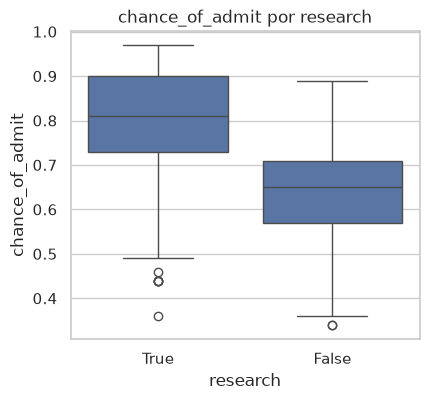

          count   mean  median    std
research                             
False       205  0.635    0.65  0.115
True        237  0.795    0.81  0.125

diferencia de medias : 0.160
t de Welch           : 14.04 (p = 3.1e-37)
d de Cohen           : 1.33  (>0.8 = efecto grande)
correlacion biserial : 0.554


In [6]:
_, ax = plt.subplots(figsize=(4.5, 4))
sns.boxplot(data=df, x=df["research"].astype("string"), y=df[TARGET], ax=ax)
ax.set_title(f"{TARGET} por research")
ax.set_xlabel("research")
plt.show()

resumen_research = df.groupby("research", observed=True)[TARGET].agg(
    ["count", "mean", "median", "std"]
)
print(resumen_research.round(3).to_string())

con_research = df.loc[df["research"].eq(True), TARGET].astype(float).dropna()
sin_research = df.loc[df["research"].eq(False), TARGET].astype(float).dropna()
t_welch, p_welch = stats.ttest_ind(con_research, sin_research, equal_var=False)
d_cohen = (con_research.mean() - sin_research.mean()) / (
    ((con_research.var() + sin_research.var()) / 2) ** 0.5
)
pareja_research = df[["research", TARGET]].dropna()
r_biserial, _ = stats.pointbiserialr(
    pareja_research["research"].astype(int), pareja_research[TARGET].astype(float)
)

print(f"\ndiferencia de medias : {con_research.mean() - sin_research.mean():.3f}")
print(f"t de Welch           : {t_welch:.2f} (p = {p_welch:.1e})")
print(f"d de Cohen           : {d_cohen:.2f}  (>0.8 = efecto grande)")
print(f"correlacion biserial : {r_biserial:.3f}")

Diferencia notable: **0.635 de media sin experiencia en investigación frente a 0.795
con ella (+0.16)**, con un *d* de Cohen de 1.33 — un efecto grande según cualquier
convención. La correlación biserial-puntual con el target es 0.554.

Ahora bien, esto es una asociación **marginal**: no dice que la investigación *cause*
una mayor probabilidad de admisión. Más abajo se ve que `research` está fuertemente
ligada a `university_rating`, y en `03.3` se comprueba si el efecto sobrevive al
controlar por esa variable.

### Ranking de asociación con el target

Las medidas anteriores no son comparables entre sí tal cual: Pearson para numéricas,
diferencia de medias para la booleana, medias por nivel para la ordinal. **Spearman sí
es comparable en los tres casos** (solo necesita que la variable se pueda ordenar),
así que se usa como criterio único.

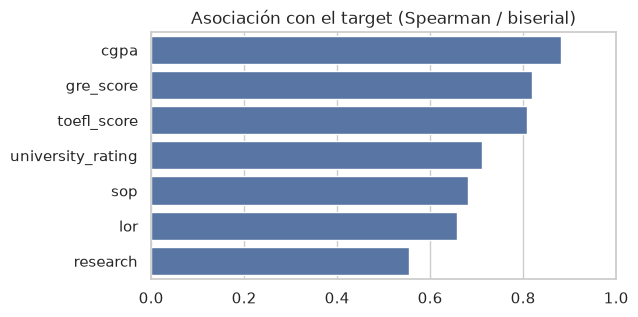

cgpa                 0.881
gre_score            0.820
toefl_score          0.809
university_rating    0.711
sop                  0.682
lor                  0.657
research             0.554
Name: |asociación| con el target, dtype: float64

In [7]:
ranking = {
    columna: item["spearman"] for columna, item in zip(COLS_NUMERICAS, correlaciones, strict=True)
}
ranking["university_rating"] = spearman_rating
ranking["research"] = r_biserial

ranking_series = (
    pd.Series(ranking, name="|asociación| con el target").abs().sort_values(ascending=False)
)

_, ax = plt.subplots(figsize=(6, 3.2))
sns.barplot(x=ranking_series.to_numpy(), y=ranking_series.index.tolist(), ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Asociación con el target (Spearman / biserial)")
plt.show()

ranking_series.round(3)

Orden final: **`cgpa` (0.88) > `gre_score` (0.82) > `toefl_score` (0.81) >
`university_rating` (0.71) > `sop` (0.68) > `lor` (0.66) > `research` (0.55)**.

Ninguna variable es irrelevante: la más débil todavía tiene una asociación de 0.55.
Eso significa que el problema es **muy predecible** con las variables disponibles, y
también que hay mucha información compartida entre ellas — lo que se confirma a
continuación.

## 🔢 Variables numéricas entre sí

Mapa de correlación de los 5 predictores numéricos más el target. Lo que se busca aquí
no es la relación con el target (ya vista), sino **redundancia entre predictores**:
dos variables con r > 0.8 aportan casi la misma información.

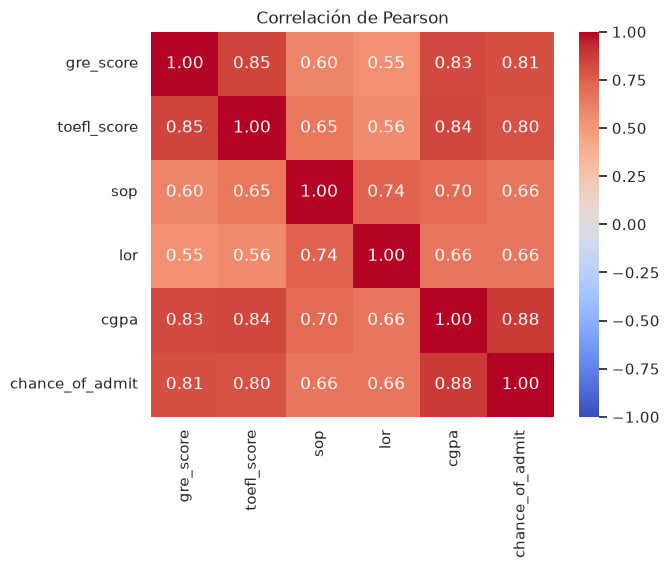

Pares de predictores con |r| > 0.8: [('gre_score', 'toefl_score', np.float64(0.846)), ('gre_score', 'cgpa', np.float64(0.834)), ('toefl_score', 'cgpa', np.float64(0.838))]


In [8]:
matriz_correlacion = df[[*COLS_NUMERICAS, TARGET]].astype(float).corr(method="pearson")

_, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Pearson")
plt.show()

UMBRAL_REDUNDANCIA = 0.8
pares_redundantes = [
    (a, b, round(matriz_correlacion.loc[a, b], 3))
    for i, a in enumerate(COLS_NUMERICAS)
    for b in COLS_NUMERICAS[i + 1 :]
    if abs(matriz_correlacion.loc[a, b]) > UMBRAL_REDUNDANCIA
]
print(f"Pares de predictores con |r| > {UMBRAL_REDUNDANCIA}: {pares_redundantes}")

**Multicolinealidad relevante:** `gre_score`–`toefl_score` (0.85), `toefl_score`–`cgpa`
(0.84) y `gre_score`–`cgpa` (0.83) superan el umbral de 0.8. Las tres miden, con
instrumentos distintos, un mismo rasgo latente: *desempeño académico*.

Consecuencia práctica: meter las tres en una regresión lineal sin regularización
produce coeficientes inestables y difíciles de interpretar (el peso se reparte de forma
arbitraria entre variables casi intercambiables). En `03.3` se cuantifica con el VIF.

`sop`–`lor` (0.74) están por debajo del umbral pero también comparten bastante: son las
dos evaluaciones cualitativas del expediente.

## 🏷️ Variables categóricas entre sí

`university_rating` vs. `research`: ¿las universidades mejor calificadas concentran a
los aspirantes con experiencia en investigación? Se usa una tabla de contingencia y una
prueba χ² de independencia.

research           False  True 
university_rating              
1                     23      5
2                     79     37
3                     71     75
4                     18     61
5                     11     59

research           False  True 
university_rating              
1                   82.1   17.9
2                   68.1   31.9
3                   48.6   51.4
4                   22.8   77.2
5                   15.7   84.3

chi2 = 80.9 (gl = 4, p = 1.1e-16)   V de Cramer = 0.429


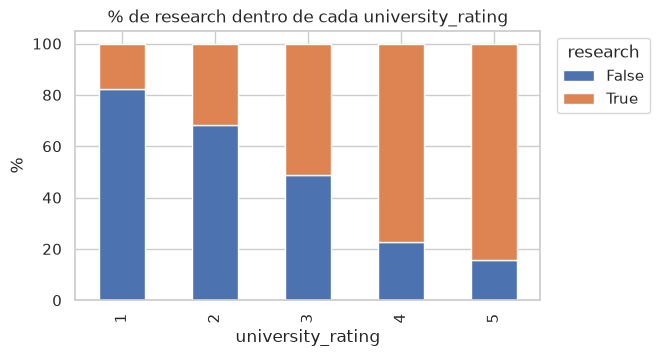

In [9]:
tabla_contingencia = pd.crosstab(df["university_rating"], df["research"])
tabla_porcentaje = pd.crosstab(df["university_rating"], df["research"], normalize="index") * 100

print(tabla_contingencia.to_string())
print()
print(tabla_porcentaje.round(1).to_string())

chi2, p_chi2, gl, _ = stats.chi2_contingency(tabla_contingencia)
v_cramer = (
    chi2 / (tabla_contingencia.to_numpy().sum() * (min(tabla_contingencia.shape) - 1))
) ** 0.5
print(f"\nchi2 = {chi2:.1f} (gl = {gl}, p = {p_chi2:.1e})   V de Cramer = {v_cramer:.3f}")

_, ax = plt.subplots(figsize=(6, 3.5))
tabla_porcentaje.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("% de research dentro de cada university_rating")
ax.set_ylabel("%")
ax.legend(title="research", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Patrón muy marcado: en `university_rating` 1 solo el **17.9 %** tiene `research = True`;
en el nivel 5 esa proporción sube al **84.3 %**. La prueba χ² rechaza la independencia
de forma contundente (χ² = 80.9, p ≈ 1e−16) con una V de Cramér de 0.43, que es una
asociación moderada-fuerte entre dos categóricas.

Las dos variables categóricas **no son independientes**: están confundidas
(*confounded*) entre sí. Parte de lo que parecía "efecto de la investigación" en el
apartado anterior podría ser, en realidad, efecto de estar en una universidad mejor
calificada.

## 🏷️🔢 Categóricas vs. numéricas

¿Los predictores numéricos también cambian según `university_rating` y `research`? Si
la respuesta es sí, refuerza la idea de que las categóricas son en buena medida un
*proxy* del mismo desempeño académico que ya miden `gre_score`, `toefl_score` y `cgpa`.

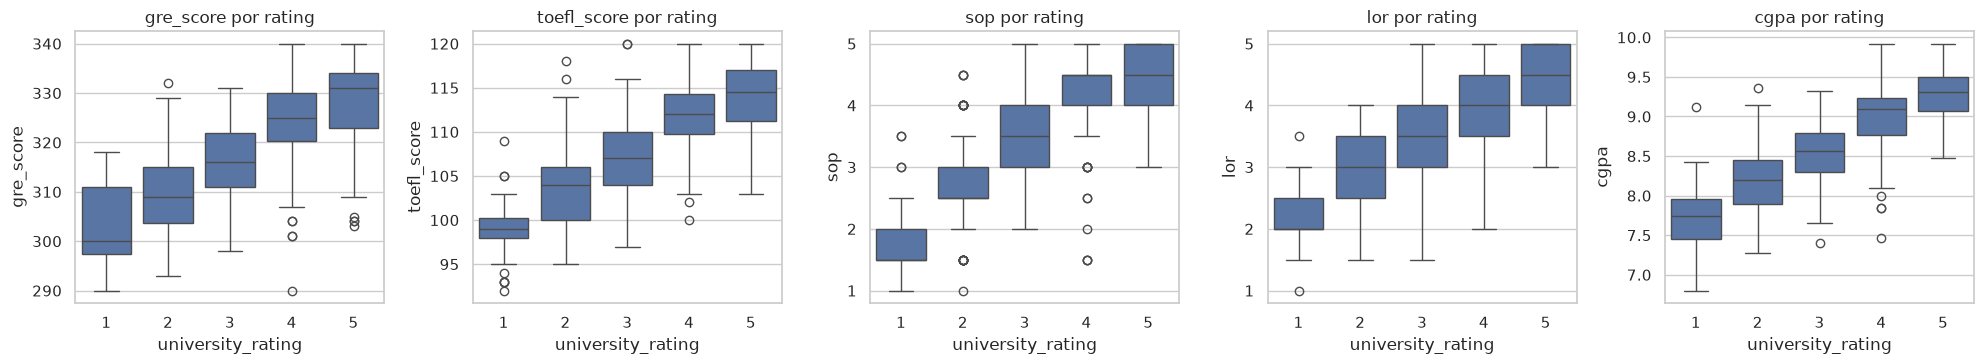

,gre_score,toefl_score,sop,lor,cgpa
university_rating,,,,,
1,302.81,99.0,1.86,2.2,7.74
2,309.14,103.48,2.73,2.93,8.17
3,315.44,106.99,3.39,3.4,8.54
4,324.12,111.86,4.07,3.98,9.0
5,328.25,113.93,4.51,4.36,9.28


In [10]:
_, axes = plt.subplots(1, len(COLS_NUMERICAS), figsize=(4 * len(COLS_NUMERICAS), 3.8))
for ax, columna in zip(axes, COLS_NUMERICAS, strict=True):
    sns.boxplot(
        data=df,
        x="university_rating",
        y=columna,
        order=sorted(df["university_rating"].dropna().unique()),
        ax=ax,
    )
    ax.set_title(f"{columna} por rating")
plt.tight_layout()
plt.show()

df.groupby("university_rating", observed=True)[COLS_NUMERICAS].mean().round(2)

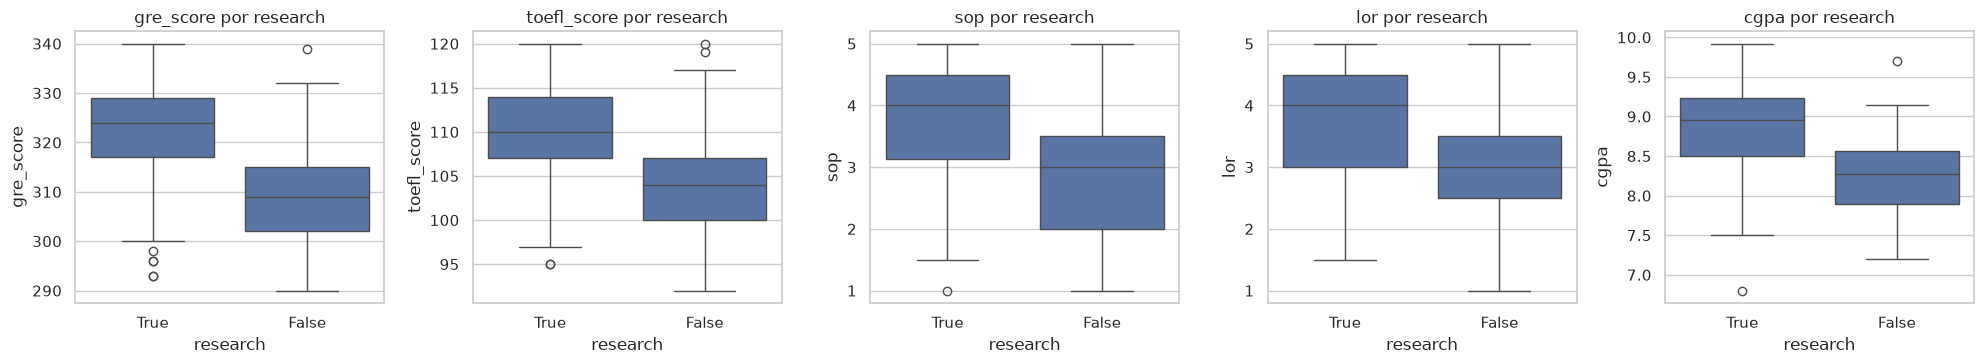

,gre_score,toefl_score,sop,lor,cgpa
research,,,,,
False,309.16,104.07,2.9,3.05,8.25
True,322.7,110.07,3.8,3.79,8.87


In [11]:
_, axes = plt.subplots(1, len(COLS_NUMERICAS), figsize=(4 * len(COLS_NUMERICAS), 3.8))
for ax, columna in zip(axes, COLS_NUMERICAS, strict=True):
    sns.boxplot(data=df, x=df["research"].astype("string"), y=df[columna], ax=ax)
    ax.set_title(f"{columna} por research")
    ax.set_xlabel("research")
plt.tight_layout()
plt.show()

df.groupby("research", observed=True)[COLS_NUMERICAS].mean().round(2)

Confirmado en los dos casos: tanto `university_rating` como `research` desplazan hacia
arriba las medianas de `gre_score`, `toefl_score` y `cgpa` de forma consistente. No son
señales independientes de esas tres variables, sino, en buena medida, **otra forma de
medir lo mismo**.

Esto explica por qué el problema resulta tan predecible: las siete variables giran
alrededor de un único eje latente de "calidad del expediente". También anticipa que
añadir todas las variables a un modelo dará mucho menos que la suma de sus
correlaciones individuales.

## 📊 Analysis of Results and Conclusions

**Ranking de asociación individual con el target** (Spearman, comparable entre tipos):

| Variable | Asociación | Tipo de medida |
|---|---|---|
| `cgpa` | 0.881 | Spearman |
| `gre_score` | 0.820 | Spearman |
| `toefl_score` | 0.809 | Spearman |
| `university_rating` | 0.711 | Spearman (ordinal) |
| `sop` | 0.682 | Spearman |
| `lor` | 0.657 | Spearman |
| `research` | 0.554 | biserial-puntual |

**Hallazgos clave:**

- Todas las relaciones con el target son **positivas, monótonas y aproximadamente
  lineales** (Pearson ≈ Spearman en todas las numéricas). Ninguna necesita
  transformación no lineal.
- `cgpa`, `gre_score` y `toefl_score` están correlacionadas entre sí entre 0.83 y 0.85:
  miden esencialmente el mismo rasgo latente. Usar las tres en un modelo lineal sin
  regularización es redundante y produce coeficientes inestables.
- `university_rating` y `research` están confundidas entre sí (χ² = 80.9, V de Cramér
  0.43) **y** con los tres predictores anteriores. Con este análisis bivariable **no se
  puede afirmar que `research` tenga un efecto propio** sobre el target.
- `sop` y `lor` aportan señal moderada y comparten bastante entre ellas (r = 0.74),
  pero son las menos redundantes con el bloque de desempeño académico.
- La diferencia de medias del target por `research` (+0.16, *d* de Cohen 1.33) es el
  contraste más grande entre grupos del dataset.

**Lo que queda abierto:** separar el efecto de cada variable *controlando por las
demás* exige mirar tres o más a la vez. Se retoma en `03.3`, junto con el VIF y el
modelo heurístico.

## 💡 Proposals and Ideas

- Para un modelo lineal interpretable, quedarse con `cgpa` (el predictor más fuerte)
  más una variable de cada bloque no redundante (`lor` o `sop`, y `research`), en vez
  de meter las siete.
- Si se quieren usar las tres variables de desempeño académico, aplicar antes PCA o
  regularización (Ridge/Lasso) para manejar la multicolinealidad.
- La confusión `university_rating` ↔ `research` ↔ desempeño académico sugiere probar un
  modelo de árboles, que captura interacciones sin necesidad de especificarlas a mano.

## 📖 References

- Análisis bivariable, Jose R. Zapata:
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/>
- `scipy.stats.chi2_contingency`:
  <https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html>
- V de Cramér como tamaño del efecto: <https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V>